In [1]:
from functools import reduce
import re
import itertools
from collections import defaultdict
from dataclasses import dataclass

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.categories import subcat_to_cat

import pickle

In [2]:
import sys
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE\evaluate')

import eval_20Minuten
import eval_CStance
import eval_FOMC
import eval_MeetingBank
import eval_NumGLUE_ds
import eval_NumGLUE_cm
import eval_PapyrusF
import eval_Py150
import eval_ScienceQA

In [3]:
All_dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm', 'Py150']                       # Benchmarks in use
tasks_to_load = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm', 'Py150']
dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm']

TRACE_base_path = r"C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE"

LoRA_cfg = 2
SemiLoRA_cfg = 2
GSOFT_cfg = 2
seq_no = 1

In [4]:
MMLU_preds_path_ls = [
    ('Raw_0sh',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_1b_0sh.bin'),
    ('Raw_5sh',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\Raw_1b_5sh.bin'),
]

for n_shots in (0, 5):
    for dataset_name in dataset_names:
        MMLU_preds_path_ls.append(
            (f'LoRA-cfg{LoRA_cfg}-{seq_no}-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\LoRA_1b-cfg{LoRA_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

    for dataset_name in dataset_names:
        MMLU_preds_path_ls.append(
            (f'SemiLoRA-cfg{SemiLoRA_cfg}-{seq_no}-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\SemiLoRA_1b-cfg{SemiLoRA_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

    for dataset_name in dataset_names:
        MMLU_preds_path_ls.append(
            (f'GSOFT-cfg{GSOFT_cfg}-{seq_no}-{dataset_name}_{n_shots}sh',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\test_preds\GSOFT_1b-cfg{GSOFT_cfg}-TRACE-seq{seq_no}-{dataset_name}-{n_shots}sh.bin'),
        )

MMLU_preds_dfs = {}

for run_name, preds_path in MMLU_preds_path_ls:
    with open(preds_path, 'rb') as f:
        MMLU_preds_dfs[run_name] = pickle.load(file=f)

        print(f"{run_name:16}: {MMLU_preds_dfs[run_name].shape=}")

Raw_0sh         : MMLU_preds_dfs[run_name].shape=(14042, 7)
Raw_5sh         : MMLU_preds_dfs[run_name].shape=(14042, 7)
LoRA-cfg2-1-20Minuten_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
LoRA-cfg2-1-FOMC_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
LoRA-cfg2-1-NumGLUE-ds_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
LoRA-cfg2-1-ScienceQA_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
LoRA-cfg2-1-C-STANCE_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
LoRA-cfg2-1-NumGLUE-cm_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-cfg2-1-20Minuten_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-cfg2-1-FOMC_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-cfg2-1-NumGLUE-ds_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-cfg2-1-ScienceQA_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-cfg2-1-C-STANCE_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
SemiLoRA-cfg2-1-NumGLUE-cm_0sh: MMLU_preds_dfs[run_name].shape=(14042, 7)
GSOFT-cfg2-1-20Minuten_0sh: MMLU_pre

In [5]:
@dataclass
class ExperimentRun:
    model_name: str
    adapter_name: str = None
    cfg: int = None
    seq: int = None
    seq_task: str = None

    def get_base_pth(self) -> str:
        path = rf"{TRACE_base_path}\preds\{self.model_name}"
        if self.adapter_name:
            path += f"-{self.adapter_name}"
        if self.cfg:
            path += f"-cfg{self.cfg}"
        if self.seq:
            path += f"\seq-{self.seq}"
        if self.seq_task:
            path += f"\{self.seq_task}"
        # path = rf"{base_path}\preds\{self.model_name}-{self.adapter_name}-cfg{self.cfg}\seq-{self.seq}\{self.seq_task}"

        return path
    
    def get_run_name(self) -> str:
        if self.adapter_name:
            run_name = self.adapter_name
        else:
            run_name = self.model_name
            
        if self.cfg:
            run_name += f"-cfg{self.cfg}"
        if self.seq:
            run_name += f"-{self.seq}"
        if self.seq_task:
            run_name += f"-{self.seq_task}"
        # run_name = f"{self.adapter_name}-cfg{self.cfg}-{self.seq}-{self.seq_task}"

        return run_name

In [6]:
TRACE_experiments = [
    ExperimentRun(model_name='Raw')
]

TRACE_experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=LoRA_cfg, seq=1, seq_task=seq_task)
    for seq_task in tasks_to_load
]

TRACE_experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=SemiLoRA_cfg, seq=1, seq_task=seq_task)
    for seq_task in tasks_to_load
]

TRACE_experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='GSOFT', cfg=GSOFT_cfg, seq=1, seq_task=seq_task)
    for seq_task in tasks_to_load
]

TRACE_experiments

[ExperimentRun(model_name='Raw', adapter_name=None, cfg=None, seq=None, seq_task=None),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='20Minuten'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='FOMC'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='NumGLUE-ds'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='ScienceQA'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='C-STANCE'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='NumGLUE-cm'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=2, seq=1, seq_task='Py150'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=2, seq=1, seq_task='20Minuten'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='SemiLoRA', cfg=2, seq=1, seq_task='FOMC'),
 ExperimentRun(model_name=

In [7]:
TRACE_preds_dict = defaultdict(lambda: dict())
for experiment in TRACE_experiments:
    run_name = experiment.get_run_name()
    print(f"Loading {run_name}")

    for dataset_name in dataset_names:
        path = rf"{experiment.get_base_pth()}\{dataset_name}.bin"

        with open(path, 'rb') as f:
            TRACE_preds_dict[run_name][dataset_name] = pickle.load(file=f)

Loading Raw
Loading LoRA-cfg2-1-20Minuten
Loading LoRA-cfg2-1-FOMC
Loading LoRA-cfg2-1-NumGLUE-ds
Loading LoRA-cfg2-1-ScienceQA
Loading LoRA-cfg2-1-C-STANCE
Loading LoRA-cfg2-1-NumGLUE-cm
Loading LoRA-cfg2-1-Py150
Loading SemiLoRA-cfg2-1-20Minuten
Loading SemiLoRA-cfg2-1-FOMC
Loading SemiLoRA-cfg2-1-NumGLUE-ds
Loading SemiLoRA-cfg2-1-ScienceQA
Loading SemiLoRA-cfg2-1-C-STANCE
Loading SemiLoRA-cfg2-1-NumGLUE-cm
Loading SemiLoRA-cfg2-1-Py150
Loading GSOFT-cfg2-1-20Minuten
Loading GSOFT-cfg2-1-FOMC
Loading GSOFT-cfg2-1-NumGLUE-ds
Loading GSOFT-cfg2-1-ScienceQA
Loading GSOFT-cfg2-1-C-STANCE
Loading GSOFT-cfg2-1-NumGLUE-cm
Loading GSOFT-cfg2-1-Py150


## MMLU evaluation

In [8]:
def get_category(subject):
    return subcat_to_cat[subject]

OOD_parts = [
    (re.compile('The correct answer is [ABCD]'), len('The correct answer is ')),
    (re.compile('The answer is [ABCD]'), len('The answer is ')),
    (re.compile('The solution is [ABCD]'), len('The solution is ')),
]

def get_pred(p):
    for OOD_part, OOD_part_len in OOD_parts:
        if OOD_part.search(p):
            return p[OOD_part_len]
    
    return p[0]

def processor(row: pd.DataFrame):
    generated_text = row['model_pred']['generated_text']
    generated_text = generated_text.strip()
    

    # generated_text	subject	pred	true	corr	category
    category = get_category(row['subject'])
    pred = get_pred(generated_text)
    true = chr(ord('A') + row['answer'])
    corr = int(pred == true)

    return {
        'generated_text': generated_text,
        'subject': row['subject'],
        'pred': pred,
        'true': true,
        'corr': corr,
        'category': category
    }

In [9]:
for run_name in MMLU_preds_dfs.keys():
    MMLU_preds_dfs[run_name] = MMLU_preds_dfs[run_name].apply(processor, axis=1, result_type='expand')

In [10]:
MMLU_acc_by_subjects = pd.DataFrame({
    'subject': list(set.union(
        *map(
            lambda df: set(df['subject']),
            MMLU_preds_dfs.values()
        )
    ))
})

print(f"Subjects: {MMLU_acc_by_subjects['subject']}")

for run_name, preds_df in MMLU_preds_dfs.items():
    acc_df = preds_df[['subject', 'corr']].groupby(['subject'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    MMLU_acc_by_subjects = MMLU_acc_by_subjects.merge(
        acc_df,
        left_on='subject',
        right_on='subject',
        how='right'
    )

Subjects: 0                         college_physics
1                college_computer_science
2                  high_school_psychology
3                         moral_scenarios
4                      conceptual_physics
5              high_school_macroeconomics
6                         college_biology
7                   professional_medicine
8                                 anatomy
9                            global_facts
10                    high_school_physics
11                       college_medicine
12                professional_psychology
13           high_school_computer_science
14                 elementary_mathematics
15                              marketing
16                high_school_mathematics
17                      logical_fallacies
18                       abstract_algebra
19                 high_school_statistics
20                             management
21                               virology
22                           econometrics
23                 high_

In [11]:
MMLU_acc_by_categories = pd.DataFrame({
    'category': list(set.union(
        *map(
            lambda df: set(df['category']),
            MMLU_preds_dfs.values()
        )
    ))
})

for run_name, preds_df in MMLU_preds_dfs.items():
    acc_df = preds_df[['category', 'corr']].groupby(['category'], as_index=False).mean()
    acc_df.rename(columns={'corr': run_name}, inplace=True)

    MMLU_acc_by_categories = MMLU_acc_by_categories.merge(
        acc_df,
        left_on='category',
        right_on='category',
        how='right'
    )

In [12]:
MMLU_total_res = pd.DataFrame(columns=['run_name', 'accuracy', 'correctness'])

for run_name, preds_df in MMLU_preds_dfs.items():
    total_accuracy = preds_df['corr'].mean()
    total_correctness = (preds_df['pred'].isin(['A', 'B', 'C', 'D'])).mean()

    MMLU_total_res = pd.concat([
        MMLU_total_res,
        pd.DataFrame({
            'run_name': [run_name],
            'accuracy': [total_accuracy],
            'correctness': [total_correctness],
        })
    ])


MMLU_total_res

C:\Users\Vladimir\AppData\Local\Temp\ipykernel_17572\2955137759.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  MMLU_total_res = pd.concat([


,run_name,accuracy,correctness
0,Raw_0sh,0.320894,0.827446
0,Raw_5sh,0.439040,0.997935
0,LoRA-cfg2-1-20Minuten_0sh,0.109742,0.245122
0,LoRA-cfg2-1-FOMC_0sh,0.374804,0.995157
0,LoRA-cfg2-1-NumGLUE-ds_0sh,0.424441,0.968452
0,LoRA-cfg2-1-ScienceQA_0sh,0.449366,0.997436
0,LoRA-cfg2-1-C-STANCE_0sh,0.377297,0.998220
0,LoRA-cfg2-1-NumGLUE-cm_0sh,0.377866,0.999573
0,SemiLoRA-cfg2-1-20Minuten_0sh,0.263282,0.570004
0,SemiLoRA-cfg2-1-FOMC_0sh,0.361985,0.875018


Text(0, 0.5, 'MMLU 5sh accuracy')

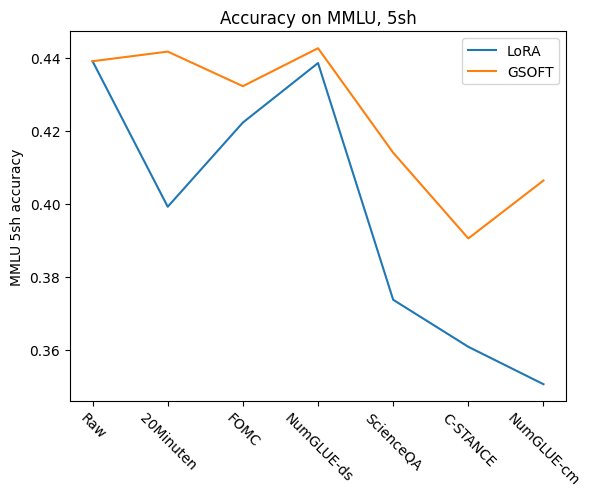

In [13]:
LoRA_scores = [MMLU_total_res[MMLU_total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
LoRA_scores += [
    MMLU_total_res[MMLU_total_res['run_name'] == f'LoRA-cfg{LoRA_cfg}-{seq_no}-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]

GSOFT_scores = [MMLU_total_res[MMLU_total_res['run_name'] == 'Raw_5sh'].accuracy[0]]
GSOFT_scores += [
    MMLU_total_res[MMLU_total_res['run_name'] == f'GSOFT-cfg{GSOFT_cfg}-{seq_no}-{dataset_name}_5sh'].accuracy[0]
    for dataset_name in dataset_names
]


plt.plot(
    range(len(dataset_names) + 1),
    LoRA_scores,
    label='LoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    GSOFT_scores,
    label='GSOFT'
)

plt.xticks(
    range(len(dataset_names) + 1),
    labels=['Raw'] + dataset_names,
    rotation=-45
)

plt.legend()

plt.title('Accuracy on MMLU, 5sh')
plt.ylabel('MMLU 5sh accuracy')

Text(0, 0.5, 'MMLU 0sh accuracy')

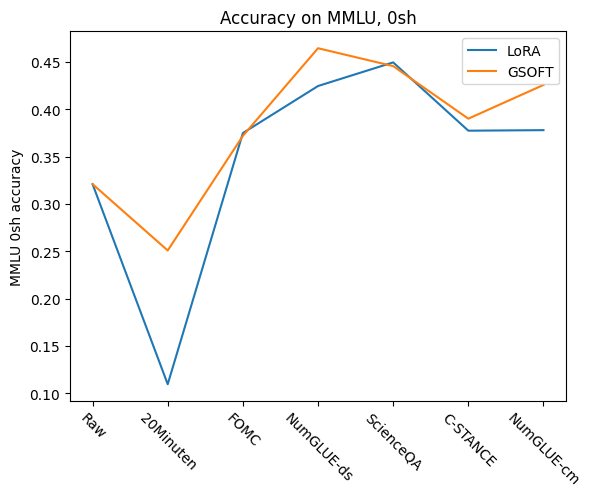

In [14]:
LoRA_scores = [MMLU_total_res[MMLU_total_res['run_name'] == 'Raw_0sh'].accuracy[0]]
LoRA_scores += [
    MMLU_total_res[MMLU_total_res['run_name'] == f'LoRA-cfg{LoRA_cfg}-{seq_no}-{dataset_name}_0sh'].accuracy[0]
    for dataset_name in dataset_names
]

GSOFT_scores = [MMLU_total_res[MMLU_total_res['run_name'] == 'Raw_0sh'].accuracy[0]]
GSOFT_scores += [
    MMLU_total_res[MMLU_total_res['run_name'] == f'GSOFT-cfg{GSOFT_cfg}-{seq_no}-{dataset_name}_0sh'].accuracy[0]
    for dataset_name in dataset_names
]


plt.plot(
    range(len(dataset_names) + 1),
    LoRA_scores,
    label='LoRA'
)

plt.plot(
    range(len(dataset_names) + 1),
    GSOFT_scores,
    label='GSOFT'
)

plt.xticks(
    range(len(dataset_names) + 1),
    labels=['Raw'] + dataset_names,
    rotation=-45
)

plt.legend()

plt.title('Accuracy on MMLU, 0sh')
plt.ylabel('MMLU 0sh accuracy')

## TRACE evaluation

In [15]:
eval_functions = {
    '20Minuten': eval_20Minuten.eval, 
    'FOMC': eval_FOMC.eval, 
    'NumGLUE-ds': eval_NumGLUE_ds.eval, 
    'ScienceQA': eval_ScienceQA.eval, 
    'C-STANCE': eval_CStance.eval, 
    'NumGLUE-cm': eval_NumGLUE_cm.eval,
    'Py150': eval_Py150.eval,
}

def calc_scores(preds_dfs):
    eval_scores = {}

    for dataset_name in dataset_names:
        print(f"Running for {dataset_name}")
        preds_df = preds_dfs[dataset_name]

        correct_answers = list(preds_df['answer'])
        model_preds = [pred['generated_text'].strip() for pred in preds_df['model_pred']]

        if dataset_name != '20Minuten':
            eval_scores[dataset_name] = eval_functions[dataset_name](model_preds, correct_answers)
        else:
            input_seq = list(preds_df['prompt'])
            eval_scores[dataset_name] = eval_functions[dataset_name](input_seq, model_preds, correct_answers)
    
    return eval_scores

In [16]:
TRACE_scores_dict = {
    run_name: calc_scores(preds_dfs)
    for run_name, preds_dfs in TRACE_preds_dict.items()
}

Running for 20Minuten


c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.

Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-cm
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for ScienceQA
Running for C-STANCE
Running for NumGLUE-c

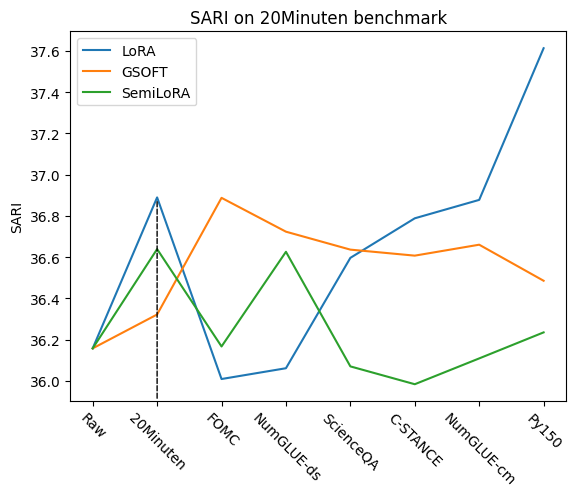

In [17]:
bench_name = '20Minuten'
exp_idx = min(idx for idx, exp in enumerate(TRACE_experiments) if exp.seq_task == bench_name)
exp_run_name = TRACE_experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['sari'][0]['sari'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['sari'][0]['sari'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['sari'][0]['sari'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

plt.annotate(
    text='',
    xy=(exp_idx, TRACE_scores_dict[exp_run_name][bench_name]['sari'][0]['sari']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in TRACE_experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('SARI')
plt.title(f'SARI on {bench_name} benchmark')
plt.legend()

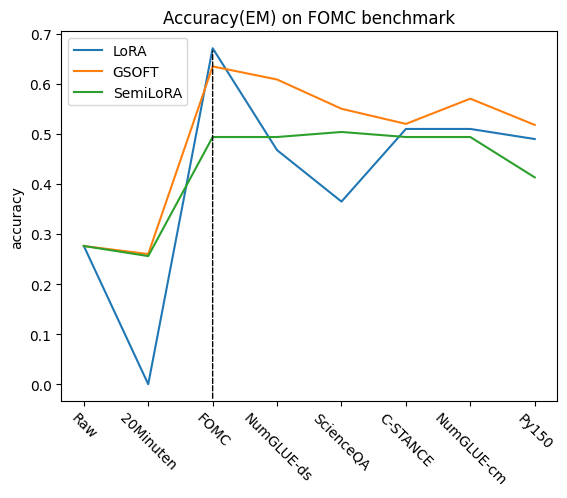

In [18]:
bench_name = 'FOMC'
exp_idx = min(idx for idx, exp in enumerate(TRACE_experiments) if exp.seq_task == bench_name)
exp_run_name = TRACE_experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, TRACE_scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in TRACE_experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

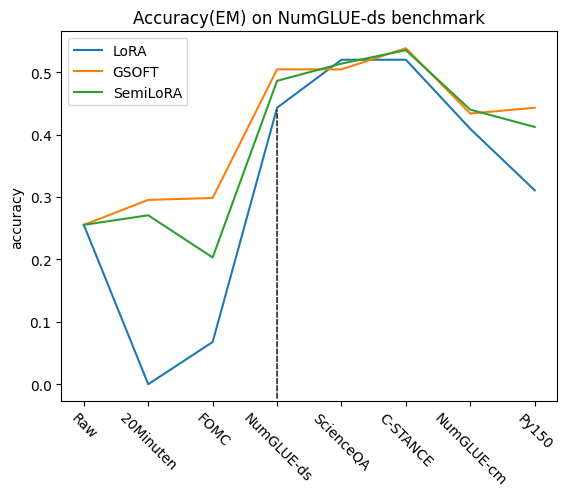

In [19]:
bench_name = 'NumGLUE-ds'
exp_idx = min(idx for idx, exp in enumerate(TRACE_experiments) if exp.seq_task == bench_name)
exp_run_name = TRACE_experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
 

# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext=(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, TRACE_scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in TRACE_experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

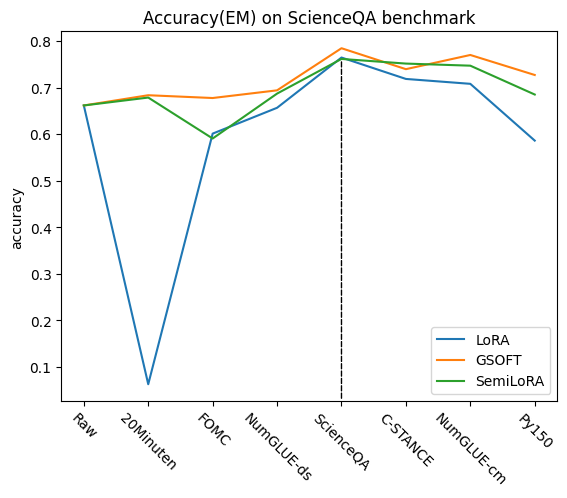

In [20]:
bench_name = 'ScienceQA'
exp_idx = min(idx for idx, exp in enumerate(TRACE_experiments) if exp.seq_task == bench_name)
exp_run_name = TRACE_experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, TRACE_scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in TRACE_experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

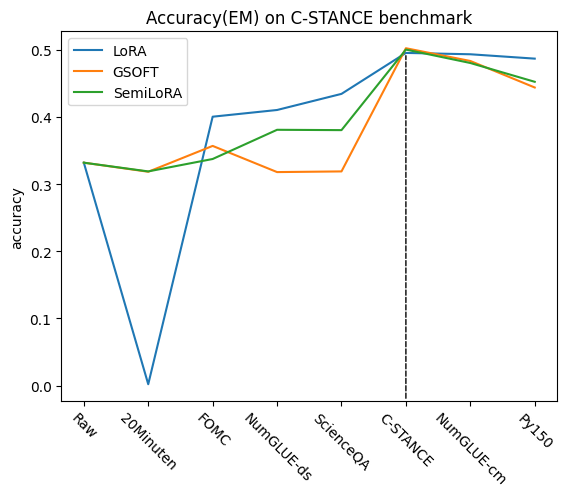

In [21]:
bench_name = 'C-STANCE'
exp_idx = min(idx for idx, exp in enumerate(TRACE_experiments) if exp.seq_task == bench_name)
exp_run_name = TRACE_experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, TRACE_scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in TRACE_experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

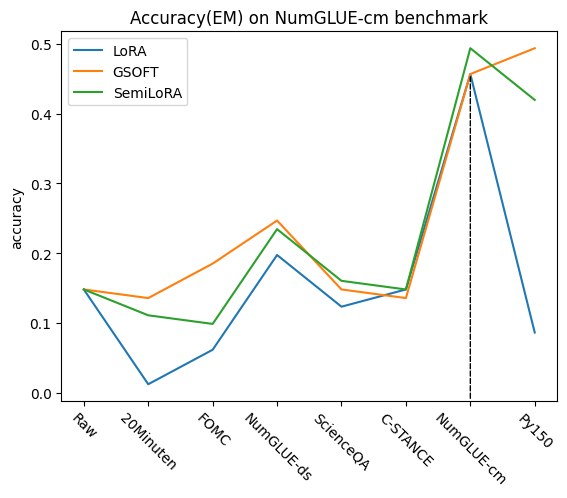

In [22]:
bench_name = 'NumGLUE-cm'
exp_idx = min(idx for idx, exp in enumerate(TRACE_experiments) if exp.seq_task == bench_name)
exp_run_name = TRACE_experiments[exp_idx].get_run_name()
x_axs = range(1 + len(tasks_to_load))


plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

plt.plot(
    x_axs,
    [TRACE_scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in TRACE_experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'SemiLoRA')],
    label='SemiLoRA'
)

# bbox = dict(boxstyle ="round", fc ="0.8") 
# arrowprops = dict( 
#     arrowstyle = "->", 
#     connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
# ) 
  
# plt.annotate(
#     text='FT', 
#     xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
#     xytext =(30, -20), 
#     textcoords ='offset points', 
#     bbox = bbox, arrowprops = arrowprops
# ) 

plt.annotate(
    text='',
    xy=(exp_idx, TRACE_scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, plt.ylim()[0]), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in TRACE_experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

## Summary

In [23]:
TRACE_experiments[0].get_run_name()

'Raw'

In [24]:
MMLU_total_res

,run_name,accuracy,correctness
0,Raw_0sh,0.320894,0.827446
0,Raw_5sh,0.439040,0.997935
0,LoRA-cfg2-1-20Minuten_0sh,0.109742,0.245122
0,LoRA-cfg2-1-FOMC_0sh,0.374804,0.995157
0,LoRA-cfg2-1-NumGLUE-ds_0sh,0.424441,0.968452
0,LoRA-cfg2-1-ScienceQA_0sh,0.449366,0.997436
0,LoRA-cfg2-1-C-STANCE_0sh,0.377297,0.998220
0,LoRA-cfg2-1-NumGLUE-cm_0sh,0.377866,0.999573
0,SemiLoRA-cfg2-1-20Minuten_0sh,0.263282,0.570004
0,SemiLoRA-cfg2-1-FOMC_0sh,0.361985,0.875018


In [25]:
All_dataset_names

['20Minuten',
 'FOMC',
 'NumGLUE-ds',
 'ScienceQA',
 'C-STANCE',
 'NumGLUE-cm',
 'Py150']

In [32]:
MMLU_total_res[MMLU_total_res['run_name'] == 'Raw_5sh']['accuracy'][0]

0.4390400227887765

Dataset FOMC: r
Dataset NumGLUE-ds: g
Dataset ScienceQA: b
Dataset C-STANCE: c
Dataset NumGLUE-cm: m


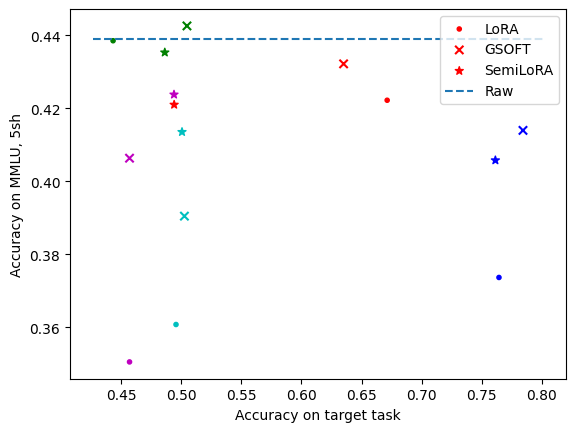

In [37]:
acc_datasets = ['FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm']
datasets_colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

for ds_name, ds_color in zip(acc_datasets, datasets_colors):
    print(f"Dataset {ds_name}: {ds_color}")

LoRA_target_scores = [
    TRACE_scores_dict[f'LoRA-cfg{LoRA_cfg}-1-{bench_name}'][bench_name]['accuracy']
    for bench_name in acc_datasets
]

LoRA_MMLU_scores = [
    MMLU_total_res[MMLU_total_res['run_name'] == f'LoRA-cfg{LoRA_cfg}-1-{bench_name}_5sh']['accuracy'][0]
    for bench_name in acc_datasets
]

SemiLoRA_target_scores = [
    TRACE_scores_dict[f'SemiLoRA-cfg{SemiLoRA_cfg}-1-{bench_name}'][bench_name]['accuracy']
    for bench_name in acc_datasets
]

SemiLoRA_MMLU_scores = [
    MMLU_total_res[MMLU_total_res['run_name'] == f'SemiLoRA-cfg{SemiLoRA_cfg}-1-{bench_name}_5sh']['accuracy'][0]
    for bench_name in acc_datasets
]

GSOFT_target_scores = [
    TRACE_scores_dict[f'GSOFT-cfg{GSOFT_cfg}-1-{bench_name}'][bench_name]['accuracy']
    for bench_name in acc_datasets
]

GSOFT_MMLU_scores = [
    MMLU_total_res[MMLU_total_res['run_name'] == f'GSOFT-cfg{GSOFT_cfg}-1-{bench_name}_5sh']['accuracy'][0]
    for bench_name in acc_datasets
]

plt.scatter(
    x=LoRA_target_scores,
    y=LoRA_MMLU_scores,
    label='LoRA',
    marker='.',
    color=datasets_colors[:len(LoRA_target_scores)],
)

plt.scatter(
    x=GSOFT_target_scores,
    y=GSOFT_MMLU_scores,
    label='GSOFT',
    marker='x',
    color=datasets_colors[:len(GSOFT_target_scores)],
)

plt.scatter(
    x=SemiLoRA_target_scores,
    y=SemiLoRA_MMLU_scores,
    label='SemiLoRA',
    marker='*',
    color=datasets_colors[:len(SemiLoRA_target_scores)],
)

plt.hlines(
    MMLU_total_res[MMLU_total_res['run_name'] == 'Raw_5sh']['accuracy'][0], 
    *plt.xlim(),
    linestyles='--', label='Raw'
)

plt.xlabel('Accuracy on target task')
plt.ylabel('Accuracy on MMLU, 5sh')
plt.legend()

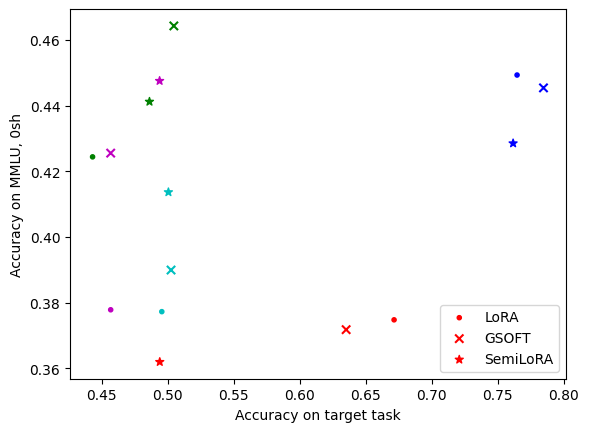

In [27]:
acc_datasets = ['FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm']
datasets_colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']

LoRA_target_scores = [
    TRACE_scores_dict[f'LoRA-cfg{LoRA_cfg}-1-{bench_name}'][bench_name]['accuracy']
    for bench_name in acc_datasets
]

LoRA_MMLU_scores = [
    MMLU_total_res[MMLU_total_res['run_name'] == f'LoRA-cfg{LoRA_cfg}-1-{bench_name}_0sh']['accuracy'][0]
    for bench_name in acc_datasets
]

SemiLoRA_target_scores = [
    TRACE_scores_dict[f'SemiLoRA-cfg{SemiLoRA_cfg}-1-{bench_name}'][bench_name]['accuracy']
    for bench_name in acc_datasets
]

SemiLoRA_MMLU_scores = [
    MMLU_total_res[MMLU_total_res['run_name'] == f'SemiLoRA-cfg{SemiLoRA_cfg}-1-{bench_name}_0sh']['accuracy'][0]
    for bench_name in acc_datasets
]

GSOFT_target_scores = [
    TRACE_scores_dict[f'GSOFT-cfg{GSOFT_cfg}-1-{bench_name}'][bench_name]['accuracy']
    for bench_name in acc_datasets
]

GSOFT_MMLU_scores = [
    MMLU_total_res[MMLU_total_res['run_name'] == f'GSOFT-cfg{GSOFT_cfg}-1-{bench_name}_0sh']['accuracy'][0]
    for bench_name in acc_datasets
]

plt.scatter(
    x=LoRA_target_scores,
    y=LoRA_MMLU_scores,
    label='LoRA',
    marker='.',
    color=datasets_colors[:len(LoRA_target_scores)],
)

plt.scatter(
    x=GSOFT_target_scores,
    y=GSOFT_MMLU_scores,
    label='GSOFT',
    marker='x',
    color=datasets_colors[:len(GSOFT_target_scores)],
)

plt.scatter(
    x=SemiLoRA_target_scores,
    y=SemiLoRA_MMLU_scores,
    label='SemiLoRA',
    marker='*',
    color=datasets_colors[:len(SemiLoRA_target_scores)],
)

plt.xlabel('Accuracy on target task')
plt.ylabel('Accuracy on MMLU, 0sh')
plt.legend()